# combined_cost_fill_rate_plot

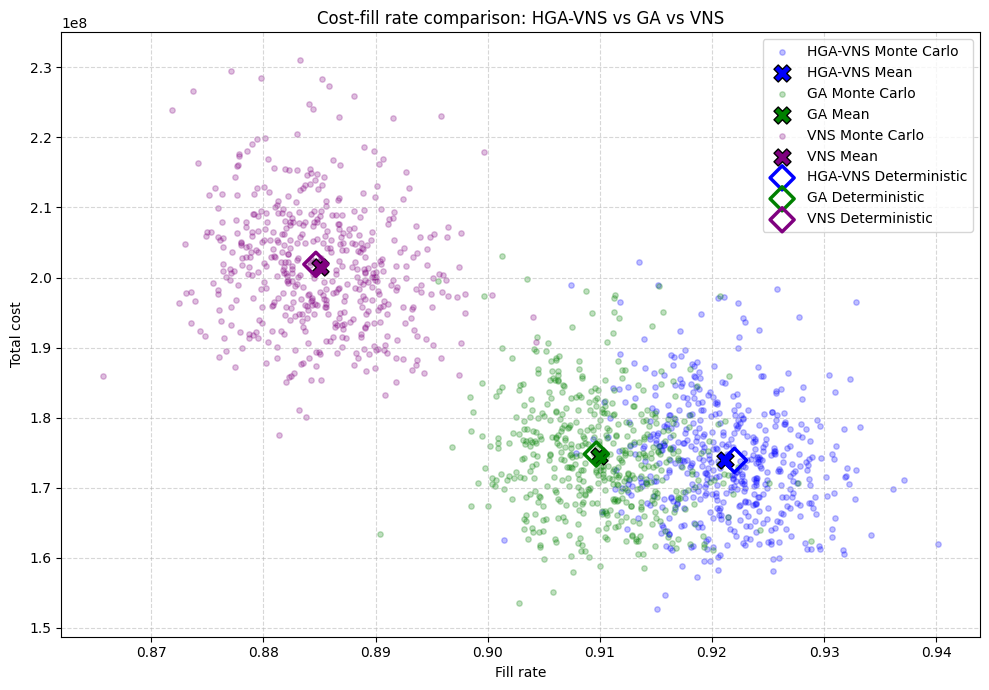

         fill_rate    total_cost
method                          
GA        0.909693  1.747941e+08
HGA-VNS   0.922009  1.739077e+08
VNS       0.884680  2.018823e+08
         fill_rate    total_cost
method                          
GA        0.909899  1.745699e+08
HGA-VNS   0.921203  1.739902e+08
VNS       0.885026  2.015161e+08
GA MC count: 500
GA DET count: 1

GA strategy breakdown:
strategy
GA Monte Carlo    500
GA                  1
Name: count, dtype: int64

GA variance:
fill_rate     5.416888e-03
total_cost    8.123103e+06
dtype: float64


In [1]:
#Load ALL results together
import pandas as pd
import matplotlib.pyplot as plt

# Load all results
df_hga = pd.read_csv("output_hga_vns/MONTE_CARLO_HGA-VNS_CANDIDATE_RUNS_6_CLEAN.csv")
df_ga  = pd.read_csv("output_ga_ipox_2/MONTE_CARLO_GA_CANDIDATE_RUNS_4_CLEAN.csv")
df_vns = pd.read_csv("output_vns/MONTE_CARLO_VNS_CANDIDATE_RUNS_4_CLEAN.csv")

# Add method label
df_hga['method'] = 'HGA-VNS'
df_ga['method']  = 'GA'
df_vns['method'] = 'VNS'

# Combine all
df_all = pd.concat([df_hga, df_ga, df_vns], ignore_index=True)

#Separate Monte Carlo vs Deterministic
df_mc  = df_all[df_all['strategy'].str.contains('Monte Carlo')]
df_det = df_all[~df_all['strategy'].str.contains('Monte Carlo')]

#Additional
# =====================================
# ✅ GLOBAL PARETO FUNCTION
# =====================================
def pareto_front_global(df):
    data = df[['total_cost', 'fill_rate']].values
    pareto_mask = [True] * len(data)

    for i, (c1, s1) in enumerate(data):
        for j, (c2, s2) in enumerate(data):
            if j != i:
                if (c2 <= c1 and s2 >= s1) and (c2 < c1 or s2 > s1):
                    pareto_mask[i] = False
                    break

    return df[pareto_mask]

# ✅ Combine ALL points (MC + deterministic)
df_combined = pd.concat([df_mc, df_det], ignore_index=True)

# ✅ Compute GLOBAL Pareto front
pareto_df = pareto_front_global(df_combined)

# ✅ Sort (important for line plotting)
pareto_sorted = pareto_df.sort_values(by='fill_rate')

#Plot COMBINED cost–fill rate
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'HGA-VNS': 'blue',
    'GA': 'green',
    'VNS': 'purple'
}

# --- Monte Carlo clouds ---
for method in df_mc['method'].unique():
    sub = df_mc[df_mc['method'] == method]
    
    ax.scatter(
        sub['fill_rate'],
        sub['total_cost'],
        alpha=0.25,
        s=15,
        color=colors[method],
        label=f"{method} Monte Carlo"
    )
    
    # Mean marker
    ax.scatter(
        sub['fill_rate'].mean(),
        sub['total_cost'].mean(),
        marker='X',
        s=150,
        color=colors[method],
        edgecolors='black',
        zorder=5,
        label=f"{method} Mean"
    )

# --- Deterministic points ---
for method in df_det['method'].unique():
    sub = df_det[df_det['method'] == method]

    x = sub['fill_rate'].iloc[0]
    y = sub['total_cost'].iloc[0]

    # ✅ Hollow diamond (always visible)
    ax.scatter(
        x,
        y,
        marker='D',
        s=150,
        facecolors='none',
        edgecolors=colors[method],
        linewidth=2.5,
        zorder=10,
        label=f"{method} Deterministic"
    )

# Labels
ax.set_xlabel('Fill rate')
ax.set_ylabel('Total cost')
ax.set_title('Cost-fill rate comparison: HGA-VNS vs GA vs VNS')

# Clean legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("combined_cost_fill_rate_all_methods.png", dpi=150)
plt.show()

# =====================================
# ✅ GLOBAL PARETO LINE
# =====================================
#ax.plot(
#    pareto_sorted['service_level'],
#    pareto_sorted['total_cost'],
#    color='black',
#    linestyle='--',
#    linewidth=2.5,
#    label='Global Pareto Front',
#    zorder=8
#)

# =====================================
# ✅ HIGHLIGHT PARETO POINTS
# =====================================
#ax.scatter(
#    pareto_df['service_level'],
#    pareto_df['total_cost'],
#    facecolors='none',
#    edgecolors='black',
#    s=100,
#    linewidth=1.5,
#    zorder=9,
#    label='Pareto Points'
#)



print(df_det.groupby('method')[['fill_rate','total_cost']].mean())
print(df_mc.groupby('method')[['fill_rate','total_cost']].mean())


print("GA MC count:", len(df_mc[df_mc['method']=='GA']))
print("GA DET count:", len(df_det[df_det['method']=='GA']))

print("\nGA strategy breakdown:")
print(df_ga['strategy'].value_counts())

print("\nGA variance:")
print(df_ga[['fill_rate','total_cost']].std())


# Option 2

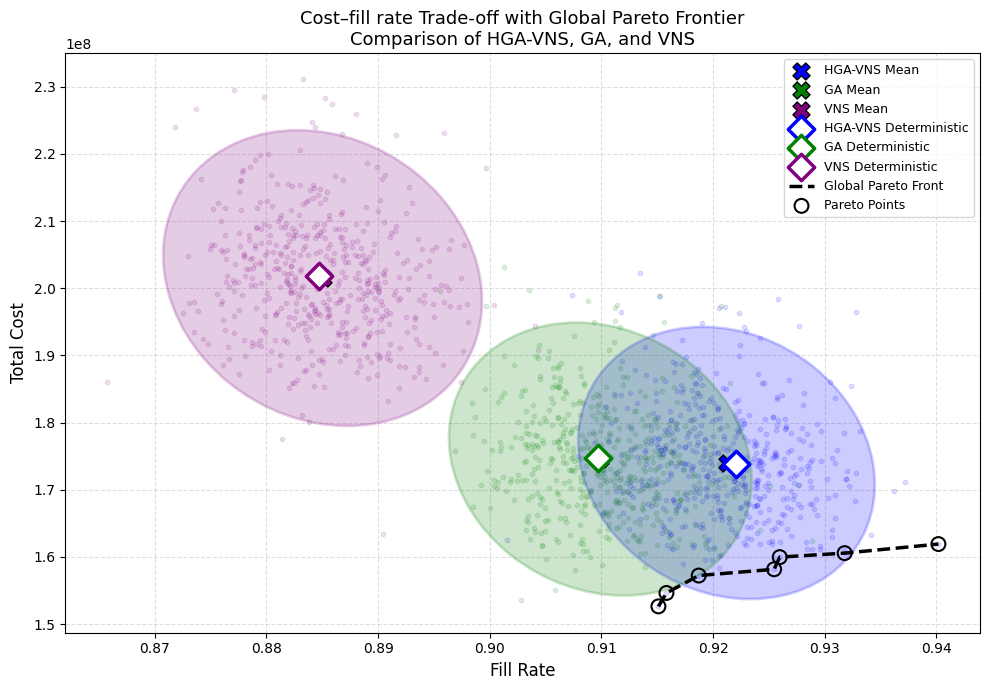


--- Deterministic ---
         fill_rate    total_cost
method                          
GA        0.909693  1.747941e+08
HGA-VNS   0.922009  1.739077e+08
VNS       0.884680  2.018823e+08

--- Monte Carlo Means ---
         fill_rate    total_cost
method                          
GA        0.909899  1.745699e+08
HGA-VNS   0.921203  1.739902e+08
VNS       0.885026  2.015161e+08

--- Pareto Points ---
      method             strategy    total_cost  fill_rate
32   HGA-VNS  HGA-VNS Monte Carlo  1.619140e+08   0.940185
50   HGA-VNS  HGA-VNS Monte Carlo  1.546320e+08   0.915824
59   HGA-VNS  HGA-VNS Monte Carlo  1.526372e+08   0.915104
294  HGA-VNS  HGA-VNS Monte Carlo  1.581612e+08   0.925470
312  HGA-VNS  HGA-VNS Monte Carlo  1.572270e+08   0.918714
365  HGA-VNS  HGA-VNS Monte Carlo  1.605673e+08   0.931784
464  HGA-VNS  HGA-VNS Monte Carlo  1.599714e+08   0.925970


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# =====================================
# ✅ LOAD DATA
# =====================================
df_hga = pd.read_csv("output_hga_vns/MONTE_CARLO_HGA-VNS_CANDIDATE_RUNS_6_CLEAN.csv")
df_ga  = pd.read_csv("output_ga_ipox_2/MONTE_CARLO_GA_CANDIDATE_RUNS_4_CLEAN.csv")
df_vns = pd.read_csv("output_vns/MONTE_CARLO_VNS_CANDIDATE_RUNS_4_CLEAN.csv")

# Add method labels
df_hga['method'] = 'HGA-VNS'
df_ga['method']  = 'GA'
df_vns['method'] = 'VNS'

# Combine
df_all = pd.concat([df_hga, df_ga, df_vns], ignore_index=True)

# Separate MC & deterministic
df_mc  = df_all[df_all['strategy'].str.contains('Monte Carlo')]
df_det = df_all[~df_all['strategy'].str.contains('Monte Carlo')]

# =====================================
# ✅ PARETO FUNCTION
# =====================================
def pareto_front_global(df):
    data = df[['total_cost', 'fill_rate']].values
    mask = [True] * len(data)

    for i, (c1, s1) in enumerate(data):
        for j, (c2, s2) in enumerate(data):
            if j != i:
                if (c2 <= c1 and s2 >= s1) and (c2 < c1 or s2 > s1):
                    mask[i] = False
                    break
    return df[mask]


# =====================================
# ✅ CONFIDENCE ELLIPSE FUNCTION
# =====================================
def plot_confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) < 2:
        return

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)

    # sort eigenvalues
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (x.mean(), y.mean()),
        width,
        height,
        angle=angle,
        facecolor=facecolor,
        **kwargs
    )

    ax.add_patch(ellipse)


# =====================================
# ✅ GLOBAL PARETO
# =====================================
df_combined = pd.concat([df_mc, df_det], ignore_index=True)
pareto_df = pareto_front_global(df_combined)
pareto_sorted = pareto_df.sort_values(by='fill_rate')

# =====================================
# ✅ PLOTTING
# =====================================
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'HGA-VNS': 'blue',
    'GA': 'green',
    'VNS': 'purple'
}

# =====================================
# ✅ MONTE CARLO + ELLIPSE
# =====================================
for method in df_mc['method'].unique():
    sub = df_mc[df_mc['method'] == method]

    x = sub['fill_rate']
    y = sub['total_cost']

    # Scatter (light)
    ax.scatter(
        x, y,
        alpha=0.12,
        s=10,
        color=colors[method],
        zorder=1
    )

    # Mean point
    ax.scatter(
        x.mean(), y.mean(),
        marker='X',
        s=150,
        color=colors[method],
        edgecolors='black',
        zorder=6,
        label=f"{method} Mean"
    )

    # ✅ Confidence ellipse
    plot_confidence_ellipse(
        x, y, ax,
        n_std=2.5,
        edgecolor=colors[method],
        facecolor=colors[method],
        alpha=0.20,
        linewidth=2,
        zorder=2
    )

# =====================================
# ✅ DETERMINISTIC POINTS
# =====================================
for method in df_det['method'].unique():
    sub = df_det[df_det['method'] == method]

    x = sub['fill_rate'].iloc[0]
    y = sub['total_cost'].iloc[0]

    ax.scatter(
        x, y,
        marker='D',
        s=180,
        facecolors='white',
        edgecolors=colors[method],
        linewidth=2.5,
        zorder=8,
        label=f"{method} Deterministic"
    )

# =====================================
# ✅ GLOBAL PARETO
# =====================================
ax.plot(
    pareto_sorted['fill_rate'],
    pareto_sorted['total_cost'],
    linestyle='--',
    color='black',
    linewidth=2.5,
    label='Global Pareto Front',
    zorder=9
)

ax.scatter(
    pareto_df['fill_rate'],
    pareto_df['total_cost'],
    facecolors='none',
    edgecolors='black',
    s=100,
    linewidth=1.5,
    zorder=10,
    label='Pareto Points'
)

# =====================================
# ✅ FORMATTING (SCI-STYLE)
# =====================================
ax.set_xlabel('Fill Rate', fontsize=12)
ax.set_ylabel('Total Cost', fontsize=12)

ax.set_title(
    'Cost–fill rate Trade-off with Global Pareto Frontier\n'
    'Comparison of HGA-VNS, GA, and VNS',
    fontsize=13
)

ax.grid(True, linestyle='--', alpha=0.4)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=9)

plt.tight_layout()
plt.savefig("SCI_cost_fill_rate_pareto.png", dpi=300)
plt.show()

# =====================================
# ✅ SUMMARY OUTPUT
# =====================================
print("\n--- Deterministic ---")
print(df_det.groupby('method')[['fill_rate','total_cost']].mean())

print("\n--- Monte Carlo Means ---")
print(df_mc.groupby('method')[['fill_rate','total_cost']].mean())

print("\n--- Pareto Points ---")
print(pareto_df[['method','strategy','total_cost','fill_rate']])
